In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path
from src.utils.paths import load_paths
from src.utils.logging import setup_logger
# CHANGED: Use sklearn metrics directly
import sklearn.metrics as skm
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_fscore_support, confusion_matrix
from src.eval.plots import plot_roc_curves, plot_pr_curves, plot_confusion_matrices, plot_probability_distributions

paths = load_paths()
logger = setup_logger(level="INFO")

# 1. Load Artifacts from Balanced Bagging Run
# Instead of re-running the ensemble creation, we load the results from the training step (Notebook 10)
logger.info("Loading Balanced Bagging Artifacts...")

bagging_dir = paths.artifacts_dir / "balanced_bagging"
metrics_path = bagging_dir / "metrics.json"
preds_path = bagging_dir / "predictions.csv" # Changed from test_predictions.csv

if not metrics_path.exists() or not preds_path.exists():
    logger.error(f"Artifacts not found in {bagging_dir}. Please run Notebook 10 first.")
    raise FileNotFoundError("Balanced Bagging artifacts missing.")

with open(metrics_path, "r") as f:
    metrics = json.load(f)

df_preds = pd.read_csv(preds_path)
# Rename 'prob' to 'p_calib' for compatibility with plotting functions if needed,
# though 'prob' is fine if we specify it. Let's standardize on 'p_calib' for this notebook.
df_preds = df_preds.rename(columns={"prob": "p_calib"})

# Ensure split column exists (it should in predictions.csv)
if "split" not in df_preds.columns:
    logger.warning("'split' column missing in predictions.csv. Assuming 'test'.")
    df_preds["split"] = "test"

logger.info(f"Loaded metrics and {len(df_preds)} predictions.")


2026-03-05 18:17:09 | INFO | ai-vpn-firewall | Loading Balanced Bagging Artifacts...
2026-03-05 18:17:09 | INFO | ai-vpn-firewall | Loaded metrics and 19908 predictions.


In [2]:
print("\n" + "="*60)
print("ADVANCED FIREWALL EVALUATION (BALANCED BAGGING ENSEMBLE)")
print("="*60)

# Extract thresholds from metrics (they are stored in the 'val' section of the new metrics structure)
# The structure from train_balanced_bagging_ensemble.py is:
# results['val']['fpr_0.001']['threshold']
val_metrics = metrics.get("val", {})

# Helper to find threshold for a target FPR
def get_threshold_from_metrics(metrics_dict, target_fpr):
    key = f"fpr_{target_fpr}"
    if key in metrics_dict:
        return metrics_dict[key]["threshold"]
    # Fallback: try string formatting
    key_str = f"fpr_{str(target_fpr)}"
    if key_str in metrics_dict:
        return metrics_dict[key_str]["threshold"]
    return 0.99

T_BLOCK = get_threshold_from_metrics(val_metrics, 0.001)
T_MONITOR = get_threshold_from_metrics(val_metrics, 0.01)

print(f"Global Policy Thresholds (tuned on VAL):")
print(f"  - BLOCK:   p >= {T_BLOCK:.4f} (Target FPR: 0.1%)")
print(f"  - MONITOR: p >= {T_MONITOR:.4f} (Target FPR: 1%)")

# Flow-Level Evaluation on Test Data
print("\n--- [1] Flow-Level Triage Performance (on TEST set) ---")
test_preds = df_preds[df_preds["split"] == "test"].copy()
y_true = test_preds["label"]
p_calib = test_preds["p_calib"]

for name, thr in [("BLOCK", T_BLOCK), ("MONITOR", T_MONITOR)]:
    y_hat = (p_calib >= thr).astype(int)
    prec, rec, _, _ = precision_recall_fscore_support(y_true, y_hat, average="binary", zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true, y_hat).ravel()
    achieved_fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    print(f"\n{name} ZONE:")
    print(f"  Recall: {rec:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  False Positives: {fp}")
    print(f"  Achieved FPR: {achieved_fpr:.5f}")

# Session-Level
print("\n--- [2] Session-Level Aggregation Performance (on TEST set) ---")
if "capture_id" in test_preds.columns:
    session_df = test_preds.groupby("capture_id").agg(
        session_score=("p_calib", "max"),
        session_label=("label", "max")
    ).reset_index()

    y_true_sess = session_df["session_label"]
    p_sess = session_df["session_score"]
    y_hat_sess_block = (p_sess >= T_BLOCK).astype(int)
    prec_sess, rec_sess, _, _ = precision_recall_fscore_support(y_true_sess, y_hat_sess_block, average="binary", zero_division=0)
    tn_s, fp_s, fn_s, tp_s = confusion_matrix(y_true_sess, y_hat_sess_block).ravel()

    print("\nSESSION BLOCK (max(p) >= T_BLOCK)")
    print(f"  - Recall:    {rec_sess:.4f}")
    print(f"  - Precision: {prec_sess:.4f}")
    print(f"  - False Positive Sessions: {fp_s} / {tn_s + fp_s}")
else:
    print("Skipping session-level eval (capture_id missing).")

# Voipbuster Case Study
print("\n--- [3] Voipbuster Case Study ---")
if "capture_id" in test_preds.columns and test_preds["capture_id"].str.contains("voipbuster").any():
    vb_mask = test_preds["capture_id"].str.contains("voipbuster")
    max_prob_vb = test_preds[vb_mask]["p_calib"].max()
    print(f"Voipbuster Max Flow Probability: {max_prob_vb:.4f}")
    if max_prob_vb >= T_BLOCK: print("  - RESULT: BLOCKED at the session level.")
    elif max_prob_vb >= T_MONITOR: print("  - RESULT: FLAGGED for monitoring.")
    else: print("  - RESULT: ALLOWED (missed).")
else:
    print("Voipbuster not found in the test set.")
print("\n" + "="*60)

# --- Per-Dataset Evaluation ---
print("\n--- Per-Dataset Evaluation (on TEST set) ---")

if "dataset" in test_preds.columns:
    test_vnat = test_preds[test_preds["dataset"] == "vnat"]
    test_iscx = test_preds[test_preds["dataset"] == "iscx"]

    for name, df_test in [("VNAT", test_vnat), ("ISCX", test_iscx)]:
        print(f"\n--- {name} TEST Performance ---")
        if df_test.empty:
            print("No test data.")
            continue

        y_true = df_test["label"]
        p_calib = df_test["p_calib"]

        auc = skm.roc_auc_score(y_true, p_calib)
        ap = skm.average_precision_score(y_true, p_calib)
        print(f"ROC AUC: {auc:.4f}")
        print(f"PR AUC:  {ap:.4f}")

        # Use Global Thresholds (Firewall Policy is usually global)
        # If we wanted per-dataset thresholds, we'd need to load them from metrics if available

        for zone, t in [("BLOCK", T_BLOCK), ("MONITOR", T_MONITOR)]:
            y_hat = (p_calib >= t).astype(int)
            prec, rec, _, _ = precision_recall_fscore_support(y_true, y_hat, average="binary", zero_division=0)
            tn, fp, fn, tp = confusion_matrix(y_true, y_hat).ravel()
            achieved_fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
            print(f"{zone} (p >= {t:.6f}): Recall={rec:.4f}, Precision={prec:.4f}, FPR={achieved_fpr:.5f} (FP={fp})")
else:
    print("WARNING: 'dataset' column missing. Skipping per-dataset evaluation.")

print("\n" + "="*60)



ADVANCED FIREWALL EVALUATION (BALANCED BAGGING ENSEMBLE)
Global Policy Thresholds (tuned on VAL):
  - BLOCK:   p >= 0.9901 (Target FPR: 0.1%)
  - MONITOR: p >= 0.9108 (Target FPR: 1%)

--- [1] Flow-Level Triage Performance (on TEST set) ---

BLOCK ZONE:
  Recall: 0.4106
  Precision: 0.9902
  False Positives: 1
  Achieved FPR: 0.00046

MONITOR ZONE:
  Recall: 0.6057
  Precision: 0.9675
  False Positives: 5
  Achieved FPR: 0.00229

--- [2] Session-Level Aggregation Performance (on TEST set) ---

SESSION BLOCK (max(p) >= T_BLOCK)
  - Recall:    0.6250
  - Precision: 0.9091
  - False Positive Sessions: 1 / 30

--- [3] Voipbuster Case Study ---
Voipbuster Max Flow Probability: 0.9952
  - RESULT: BLOCKED at the session level.


--- Per-Dataset Evaluation (on TEST set) ---

--- VNAT TEST Performance ---
ROC AUC: 0.9955
PR AUC:  0.8300
BLOCK (p >= 0.990115): Recall=0.5000, Precision=0.8571, FPR=0.00127 (FP=1)
MONITOR (p >= 0.910807): Recall=0.7500, Precision=0.7500, FPR=0.00380 (FP=3)

--- IS


--- Generating Plots for Ensemble ---


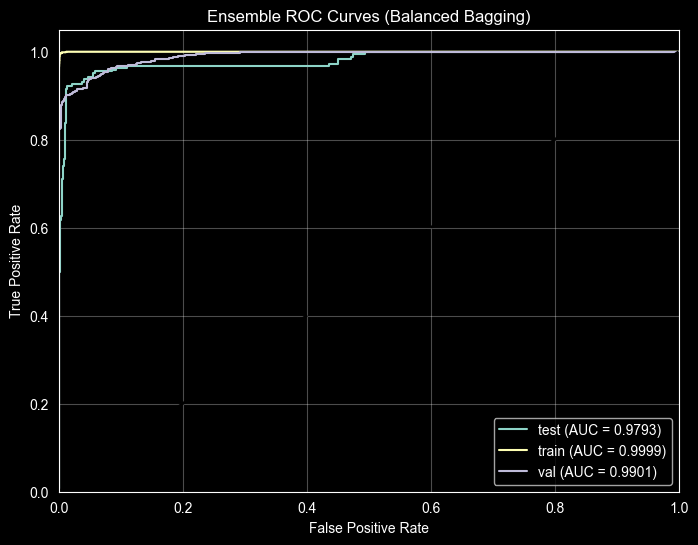

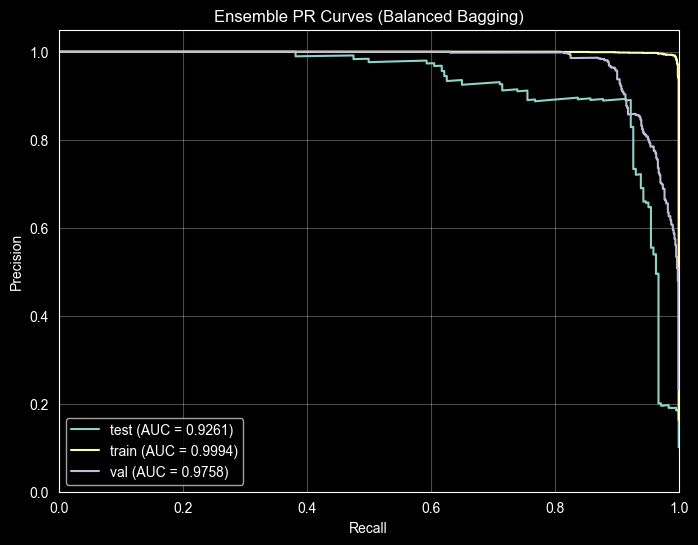

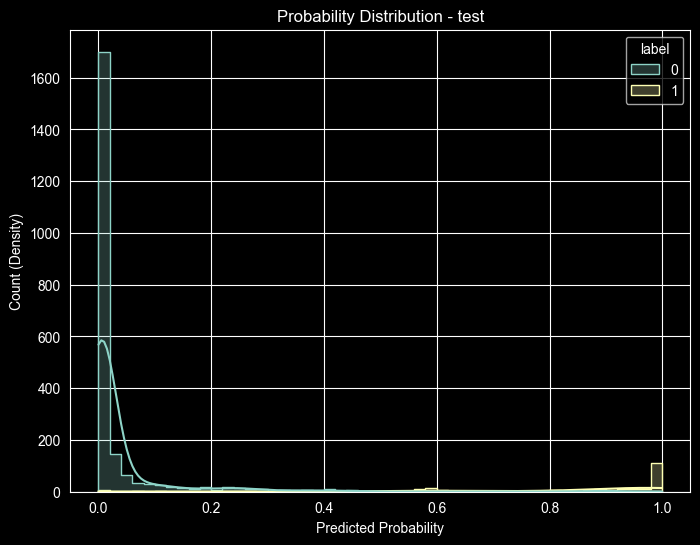

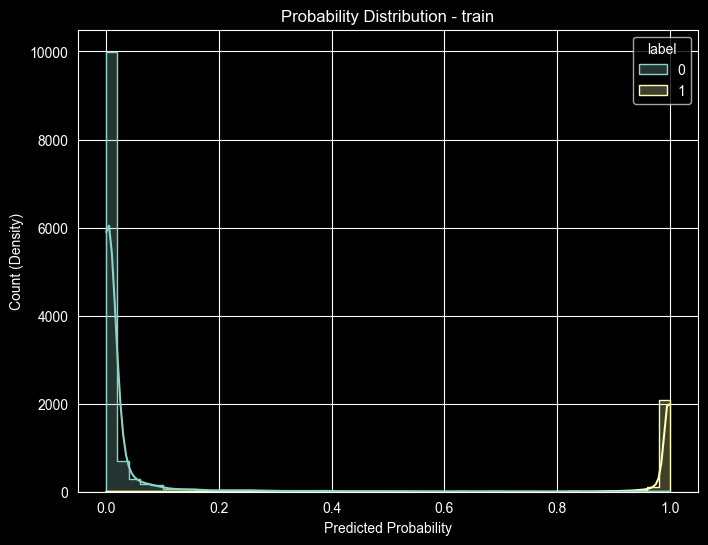

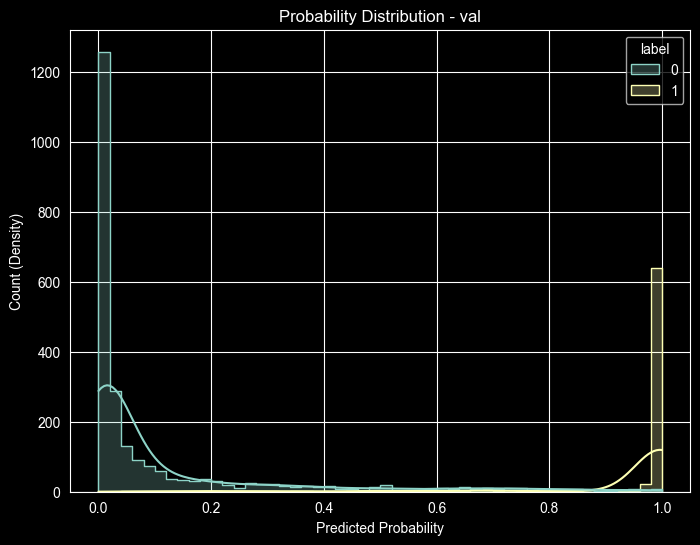


--- Confusion Matrices at Policy Thresholds (Test Set) ---


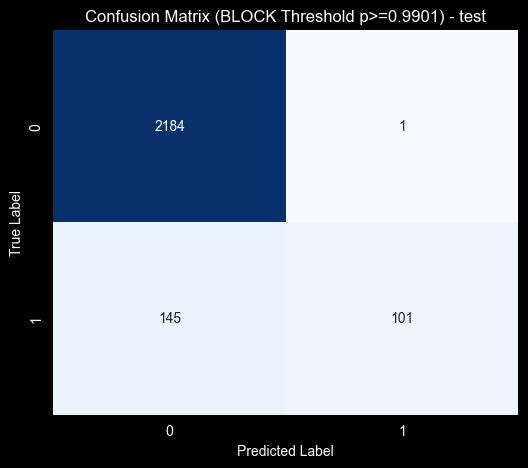

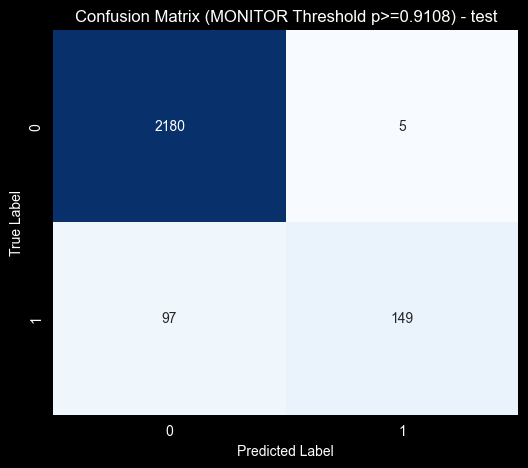

In [3]:
# 4. Visualization
print("\n--- Generating Plots for Ensemble ---")
# plot_roc_curves handles multiple splits automatically if 'split' column is present
plot_roc_curves(df_preds, prob_col="p_calib", title="Ensemble ROC Curves (Balanced Bagging)")
plot_pr_curves(df_preds, prob_col="p_calib", title="Ensemble PR Curves (Balanced Bagging)")
plot_probability_distributions(df_preds, prob_col="p_calib")

# NEW: Confusion Matrices for BLOCK and MONITOR thresholds
print("\n--- Confusion Matrices at Policy Thresholds (Test Set) ---")
# We explicitly filter for test set for confusion matrices to avoid clutter
test_preds = df_preds[df_preds["split"] == "test"]
plot_confusion_matrices(test_preds, prob_col="p_calib", threshold=T_BLOCK, title=f"Confusion Matrix (BLOCK Threshold p>={T_BLOCK:.4f})")
plot_confusion_matrices(test_preds, prob_col="p_calib", threshold=T_MONITOR, title=f"Confusion Matrix (MONITOR Threshold p>={T_MONITOR:.4f})")
